# Simulation of a 2-DOF Planar Manipulator for Logo Tracing

Okay so before I start with this, I'll just explain my approach. We need to trace the IIT KGP Logo using a Robotic Arm Having 2 Degrees of Freedom. Since it's tough to basically find all the points manually and feed it into the robotic arm algorithm, I've created a copy of the KGP Logo that basically contains only edges in it. Let me show you...
<div align="center">
    <img src="../data/kgp_logo.png" width="350">
</div>

Now, since we have only 2 DOF, the arm cannot lift the pen up, i.e. it must draw without lifting the pen up. Thus, it cannot draw between disconnected points. So if you observe the image closely, I've connected as many chunks of white pixels as possible (I used Canva for that). Now I just have to write a function to find and store these points so that it can use it for drawing later.

In [1]:
# First I'll import important modules
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Extracting Largest Component

Now I'm going to write a function that basically takes in the image part and checks for the largest connected component of white pixels (since I've made the image that way). It'll basically take all the pixels which are non-black after thresholding so yeah even different shades of white work. That's how editing in canva turned out helpful.

In [2]:
# Now this function should take in an edge-detected image and extracts pixels as (x, y) coords
def extract_largest_component(image_path):
    # Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}. Check the path.")

    # Threshold the image to ensure pure binary (white edges, black background)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Find connected components
    # connectivity=8 means diagonals are considered connected
    # (Took me some effort to find that out and fix it)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # Find the largest component (excluding label 0, which is the black background)
    largest_label = 1
    max_area = 0
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > max_area:
            max_area = stats[i, cv2.CC_STAT_AREA]
            largest_label = i

    # Extract the coordinates of the largest component
    # np.where returns (row, col) which translates to (y, x). 
    # We invert it to standard (x, y) Cartesian coordinates for the robot.
    y_coords, x_coords = np.where(labels == largest_label)
    
    # In images, Y goes down. For a robot workspace, we usually want Y going up.
    # We will flip the Y coordinates based on the image height.
    height = img.shape[0]
    points = np.column_stack((x_coords, height - y_coords))

    print(f"Extraction complete: Found {len(points)} points in the largest component.")
    
    return points

Now that we have that function, we might also want a function to visually confirm that our points are right. Otherwise there'll be problems later in the program. So I guess we go onto that.

# Visualise Extracted Points

In [3]:
def visualize_points(points):
    # Slice the numpy array into separate X and Y lists
    x = points[:, 0]
    y = points[:, 1]

    plt.figure(figsize=(8, 8))
    
    # Scatter plot with small dot markers
    plt.scatter(x, y, s=1, c='blue', marker='.')
    
    plt.title("Extracted Raw Points (Robot Workspace)")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    
    # Force the axes to have the same scale so the logo isn't stretched
    plt.axis('equal') 
    plt.grid(True)
    plt.show()

I realised I haven't really called the functions, so I'll just do that now.

# Calling Functions on Edge-Detected Image

Extraction complete: Found 5307 points in the largest component.


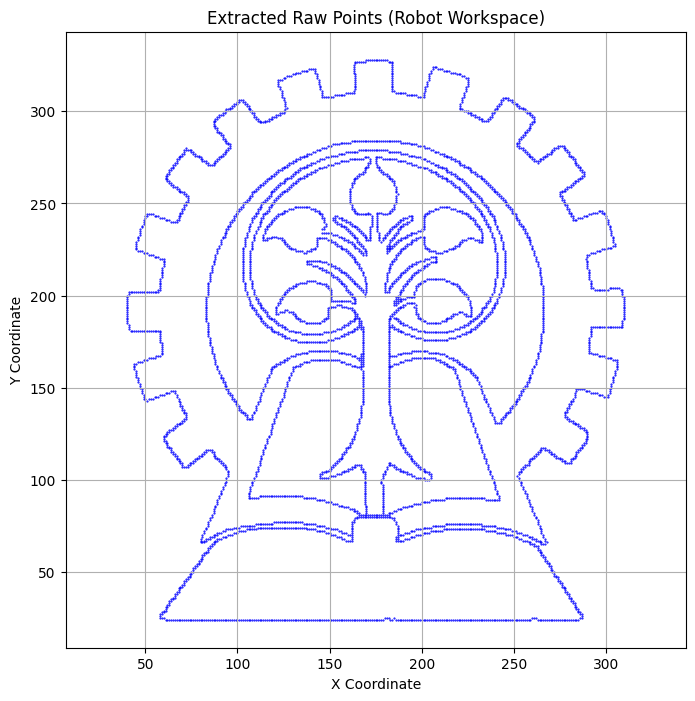

In [4]:
raw_points = extract_largest_component('../data/kgp_logo.png')
visualize_points(raw_points)